<p align='center'>
<a href='https://github.com/bono-p/minillm_v2'><img src='https://img.shields.io/badge/GitHub-bono--p%2Fminillm__v2-181717?style=for-the-badge&logo=github'/></a>
&nbsp;
<a href='https://colab.research.google.com/github/bono-p/minillm_v2/blob/main/MiniLLM_v2_DevLab.ipynb'><img src='https://colab.research.google.com/assets/colab-badge.svg' height='28'/></a>
</p>

# 🧠 MiniLLM v2 — DevLab

Transformer decoder-only moderne, entraînable sur GPU Colab gratuit (T4).
Architecture : **RoPE · RMSNorm · SwiGLU · GQA · Flash Attention**

---

## 🗺️ Plan

| # | Section | Description |
|---|---------|-------------|
| **0** | Variables globales | Chemins Drive définis une seule fois |
| **1** | Setup | GPU · Drive · Dépendances · Repo GitHub |
| **2** | Architecture | Choisir et inspecter la taille du modèle |
| **3** | Datasets | Wikipedia FR · PIAF QA (HuggingFace) |
| **4** | Tokenisation | Préparer les `.bin` d'entraînement (dtype int32) |
| **5** | Pré-entraînement | Entraîner sur Wikipedia FR |
| **6** | Fine-tuning QA | Spécialiser sur PIAF |
| **7** | Génération | Tester le modèle |
| **8** | Sauvegarde | Drive · Rolling checkpoints · Export |

> ⚡ **GPU requis** : `Exécution > Modifier le type d'exécution > GPU (T4)`  
> ▶️ Exécute les cellules **dans l'ordre** de haut en bas.


---
## 0️⃣ Variables globales
> Définis ici tous tes chemins Drive. Le reste du notebook les utilise automatiquement.


In [1]:
# @title ⚙️ 0.1 — Chemins et paramètres globaux
# ── Personalise ici si besoin ──────────────────────────
GITHUB_USER   = 'bono-p'              # @param {type:'string'}
GITHUB_REPO   = 'minillm_v2'         # @param {type:'string'}
DRIVE_BASE    = '/content/drive/MyDrive/MiniLLM_v2'  # @param {type:'string'}
MODEL_SIZE    = '50M'                 # @param ['15M','50M','125M','350M']
ROLLING_KEEP  = 2                     # @param {type:'slider',min:1,max:5,step:1}
# ───────────────────────────────────────────────────────

import os

REPO_DIR       = f'/content/{GITHUB_REPO}'
DATA_DIR       = f'{DRIVE_BASE}/data'
PRETRAIN_BIN   = f'{DATA_DIR}/pretrain'
FINETUNE_BIN   = f'{DATA_DIR}/finetune'
CKPT_PRETRAIN  = f'{DRIVE_BASE}/checkpoints/pretrain'
CKPT_FINETUNE  = f'{DRIVE_BASE}/checkpoints/finetune'
WIKI_CACHE     = None   # défini à la section 3.1
PIAF_CACHE     = f'{DATA_DIR}/piaf_qa.json'
PRETRAIN_TRAIN = f'{PRETRAIN_BIN}/train.bin'
PRETRAIN_VAL   = f'{PRETRAIN_BIN}/val.bin'
FINETUNE_TRAIN = f'{FINETUNE_BIN}/train.bin'
FINETUNE_VAL   = f'{FINETUNE_BIN}/val.bin'

print('✅ Variables globales définies')
print(f'  Drive base   : {DRIVE_BASE}')
print(f'  Modèle       : MiniLLM-{MODEL_SIZE}')
print(f'  Rolling keep : {ROLLING_KEEP} checkpoints numérotés max')


✅ Variables globales définies
  Drive base   : /content/drive/MyDrive/MiniLLM_v2
  Modèle       : MiniLLM-50M
  Rolling keep : 2 checkpoints numérotés max


---
## 1️⃣ Setup


In [2]:
# @title 🖥️ 1.1 — Vérification GPU
import subprocess, torch

res = subprocess.run(
    ['nvidia-smi','--query-gpu=name,memory.total,memory.free','--format=csv,noheader'],
    capture_output=True, text=True
)
if res.returncode == 0:
    print(f'✅ GPU : {res.stdout.strip()}')
else:
    print('❌ Aucun GPU détecté !')
    print('   → Exécution > Modifier le type d\'exécution > GPU (T4)')
    raise SystemExit('GPU requis pour entraîner MiniLLM v2')

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
print(f'BF16     : {torch.cuda.is_bf16_supported()}')
DEVICE = 'cuda'


✅ GPU : Tesla T4, 15360 MiB, 14913 MiB
PyTorch  : 2.11.0+cu128
CUDA     : 12.8
BF16     : True


In [3]:
# @title 📦 1.2 — Installation des dépendances
%%capture cap
import subprocess
subprocess.run(['pip','install','tiktoken','datasets','-q'], check=True)

import tiktoken, datasets, numpy, torch
print(f'✅ tiktoken  {tiktoken.__version__}')
print(f'✅ datasets  {datasets.__version__}')
print(f'✅ numpy     {numpy.__version__}')
print(f'✅ torch     {torch.__version__}')


In [6]:
# @title 💾 1.3 — Montage Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# Créer tous les dossiers nécessaires
for d in [DATA_DIR, PRETRAIN_BIN, FINETUNE_BIN, CKPT_PRETRAIN, CKPT_FINETUNE]:
    os.makedirs(d, exist_ok=True)

print('✅ Google Drive monté')
print(f'  📁 Données          : {DATA_DIR}')
print(f'  📁 Ckpt pré-entr.   : {CKPT_PRETRAIN}')
print(f'  📁 Ckpt fine-tuning : {CKPT_FINETUNE}')


Mounted at /content/drive
✅ Google Drive monté
  📁 Données          : /content/drive/MyDrive/MiniLLM_v2/data
  📁 Ckpt pré-entr.   : /content/drive/MyDrive/MiniLLM_v2/checkpoints/pretrain
  📁 Ckpt fine-tuning : /content/drive/MyDrive/MiniLLM_v2/checkpoints/finetune


In [8]:
# @title 📂 1.4 — Clonage du repo GitHub
import os, sys

if os.path.exists(REPO_DIR):
    print('Mise à jour du repo...')
    !cd {REPO_DIR} && git pull -q
else:
    url = f'https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git'
    print(f'Clonage depuis {url}...')
    !git clone {url} {REPO_DIR} -q

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.chdir(REPO_DIR)
print(f'✅ Repo prêt dans {REPO_DIR}')
py_files = sorted(f for f in os.listdir('.') if f.endswith('.py'))
print(f'   Fichiers Python : {py_files}')


Mise à jour du repo...
✅ Repo prêt dans /content/minillm_v2
   Fichiers Python : ['config.py', 'generate.py', 'inspect_model.py', 'model.py', 'prepare_data.py', 'push_to_github.py', 'train.py']


---
## 2️⃣ Architecture du modèle
> Choisis la taille adaptée à ton GPU. Pour Colab T4 (15 GB VRAM) : **15M ou 50M** recommandé.


In [9]:
# @title 📊 2.1 — Tableau comparatif des presets
from config import PRESETS

print(f'  {"Size":>6} | {"Params":>7} | {"Layers":>6} | {"d_model":>7} | '
      f'{"Heads Q":>7} | {"KV":>4} | {"FFN":>5} | {"Ctx":>5} | GPU')
print('  ' + '─'*70)
for name, cfg in PRESETS.items():
    n    = cfg.count_params()
    typ  = 'MHA' if cfg.kv_heads == cfg.n_heads else f'GQA×{cfg.n_heads//cfg.kv_heads}'
    vram = n*4*4/1e9
    gpu  = '✅ T4' if vram < 13 else ('⚠️ Pro' if vram < 40 else '🔴 A100')
    print(f'  {name:>6} | {n/1e6:>5.1f}M | {cfg.n_layers:>6} | {cfg.d_model:>7} | '
          f'{cfg.n_heads:>7} | {typ:>4} | {cfg.ffn_hidden:>5} | {cfg.max_seq_len:>5} | {gpu}')


    Size |  Params | Layers | d_model | Heads Q |   KV |   FFN |   Ctx | GPU
  ──────────────────────────────────────────────────────────────────────
     15M |  49.1M |      6 |     384 |       6 |  MHA |  1024 |  1024 | ✅ T4
     50M |  83.5M |     10 |     512 |       8 |  MHA |  1408 |  1024 | ✅ T4
    125M | 162.0M |     12 |     768 |      12 |  MHA |  2048 |  1024 | ✅ T4
    350M | 381.1M |     24 |    1024 |      16 | GQA×2 |  2752 |  2048 | ✅ T4
      1B | 1091.5M |     20 |    2048 |      16 | GQA×4 |  5504 |  4096 | ⚠️ Pro


In [10]:
# @title 🔬 2.2 — Inspecter le modèle choisi
import torch, math, sys
sys.path.insert(0, REPO_DIR)
from config import PRESETS
from model  import MiniLLM

cfg   = PRESETS[MODEL_SIZE]
model = MiniLLM(cfg)
n     = model.n_params
n_emb = cfg.vocab_size * cfg.d_model
n_blk = sum(p.numel() for nm,p in model.named_parameters() if 'blocks' in nm)

print(f'{'═'*52}')
print(f'  MiniLLM-{MODEL_SIZE}  ({n/1e6:.2f}M paramètres)')
print(f'{'═'*52}')
print(f'  Embedding  : {n_emb/1e6:.2f}M  ({n_emb/n*100:.0f}%)')
print(f'  Blocs ×{cfg.n_layers}   : {n_blk/1e6:.2f}M  ({n_blk/n*100:.0f}%)')
print(f'  LM Head    : {"partagé (tie_embeddings)" if cfg.tie_embeddings else "séparé"}')
print(f'  VRAM entr  : ~{n*4*4/1e9:.2f} GB')
print()

x = torch.randint(0, cfg.vocab_size, (2, 64))
with torch.no_grad():
    logits, loss = model(x, x)
expected = math.log(cfg.vocab_size)
print(f'  ✅ Forward OK  |  Loss initiale : {loss.item():.3f}  (attendu ≈ {expected:.2f})')
print(f'{'═'*52}')


════════════════════════════════════════════════════
  MiniLLM-50M  (83.47M paramètres)
════════════════════════════════════════════════════
  Embedding  : 51.34M  (62%)
  Blocs ×10   : 32.12M  (38%)
  LM Head    : partagé (tie_embeddings)
  VRAM entr  : ~1.34 GB

  ✅ Forward OK  |  Loss initiale : 9.969  (attendu ≈ 11.52)
════════════════════════════════════════════════════


---
## 3️⃣ Téléchargement des datasets
Les fichiers sont mis en **cache sur Drive** → pas re-téléchargés si tu relances.

| Dataset | Source | Usage |
|---------|--------|-------|
| **Wikipedia FR** | `wikimedia/wikipedia` (HuggingFace) | Pré-entraînement |
| **PIAF** | `etalab-ia/piaf` (HuggingFace) | Fine-tuning QA |


In [ ]:
# @title 📰 3.1 — Wikipedia français (pré-entraînement)
import os, sys
from datasets import load_dataset

WIKI_FRACTION = '2%'  # @param ['1%','2%','5%','10%','20%','100%']

WIKI_CACHE = f'{DATA_DIR}/wikipedia_fr_{WIKI_FRACTION.replace("%","p")}.txt'

if os.path.exists(WIKI_CACHE) and os.path.getsize(WIKI_CACHE) > 1000:
    size_mb = os.path.getsize(WIKI_CACHE)/1e6
    print(f'✅ Cache Drive : {WIKI_CACHE}  ({size_mb:.0f} MB) — pas de re-téléchargement')
else:
    print(f'Téléchargement Wikipedia FR ({WIKI_FRACTION})...')
    # Identifiant correct HuggingFace 2024 : wikimedia/wikipedia
    wiki = load_dataset(
        'wikimedia/wikipedia',
        '20231101.fr',
        split=f'train[:{WIKI_FRACTION}]',
        trust_remote_code=False,
    )
    print(f'  {len(wiki):,} articles chargés — écriture vers Drive...')
    chars = 0
    with open(WIKI_CACHE, 'w', encoding='utf-8') as f:
        for i, art in enumerate(wiki):
            text = art['title'] + '\n\n' + art['text'] + '\n\n'
            f.write(text)
            chars += len(text)
            if (i+1) % 5000 == 0:
                print(f'  {i+1:,} articles — {chars/1e6:.0f} MB', end='\r')
    size_mb = os.path.getsize(WIKI_CACHE)/1e6
    print(f'\n✅ Sauvegardé : {WIKI_CACHE}  ({size_mb:.0f} MB)')

# Aperçu
with open(WIKI_CACHE, encoding='utf-8') as f:
    preview = f.read(350)
print(f'\nAperçu :\n{"─"*44}\n{preview}\n{"─"*44}')


✅ Cache Drive : /content/drive/MyDrive/MiniLLM_v2/data/wikipedia_fr_2p.txt  (630 MB) — pas de re-téléchargement

Aperçu :
────────────────────────────────────────────
Antoine Meillet

Antoine Meillet, né le  à Moulins (Allier) et mort le  à Châteaumeillant (Cher), est un philologue français, le principal linguiste français des premières décennies du .

Biographie

Enfance et formation 
Paul Jules Antoine Meillet est d'origine bourbonnaise, fils d'un notaire de Châteaumeillant (Cher). Il naît à Moulins le 11 nove
────────────────────────────────────────────


In [11]:
# @title ❓ 3.2 — PIAF : dataset QA français (3 835 paires)
import os, json
from datasets import load_dataset

if os.path.exists(PIAF_CACHE) and os.path.getsize(PIAF_CACHE) > 100:
    with open(PIAF_CACHE, encoding='utf-8') as f:
        piaf_data = json.load(f)
    print(f'✅ Cache Drive : {PIAF_CACHE}  ({len(piaf_data)} exemples)')
else:
    print('Téléchargement PIAF (etalab-ia/piaf)...')
    piaf = load_dataset('etalab-ia/piaf', split='train', trust_remote_code=False)
    piaf_data = []
    for ex in piaf:
        answers = ex['answers']['text']
        if not answers:
            continue
        piaf_data.append({
            'context':  ex['context'][:800],
            'question': ex['question'],
            'answer':   answers[0],
        })
    with open(PIAF_CACHE, 'w', encoding='utf-8') as f:
        json.dump(piaf_data, f, ensure_ascii=False, indent=1)
    print(f'✅ PIAF sauvegardé : {len(piaf_data)} exemples → {PIAF_CACHE}')

# Aperçu de 2 exemples
print(f'\n── Exemples PIAF ──────────────────────────────')
for ex in piaf_data[:10]:
    print(f'  Q : {ex["question"]}')
    print(f'  R : {ex["answer"]}')
    print()


✅ Cache Drive : /content/drive/MyDrive/MiniLLM_v2/data/piaf_qa.json  (3835 exemples)

── Exemples PIAF ──────────────────────────────
  Q : Combien de personnes travaillent au ministère des sports
  R : 100 000

  Q : Combien d'employeurs
  R : 20 000



---
## 4️⃣ Tokenisation
> Conversion texte → tokens → fichiers `.bin` en **int32**.

> ⚠️ **Pourquoi int32 ?**  
> cl100k_base a 100 277 tokens → uint16 max = 65 535 → **overflow pour les tokens > 65k**.  
> int32 gère jusqu'à 2 milliards → aucun problème.


In [ ]:
# @title 🔡 4.1 — Tokeniser Wikipedia FR (pré-entraînement)
import os, sys, time
import numpy as np
import tiktoken
sys.path.insert(0, REPO_DIR)

# Vérifier si déjà tokenisé et valide
if (os.path.exists(PRETRAIN_TRAIN) and os.path.getsize(PRETRAIN_TRAIN) > 0 and
    os.path.exists(PRETRAIN_VAL)   and os.path.getsize(PRETRAIN_VAL)   > 0):
    n_tr = len(np.memmap(PRETRAIN_TRAIN, dtype=np.int32, mode='r'))
    n_vl = len(np.memmap(PRETRAIN_VAL,   dtype=np.int32, mode='r'))
    print(f'✅ Déjà tokenisé sur Drive — pas de re-traitement')
    print(f'   Train : {n_tr:,} tokens  |  Val : {n_vl:,} tokens (int32)')
else:
    assert WIKI_CACHE and os.path.exists(WIKI_CACHE) and os.path.getsize(WIKI_CACHE) > 0, (
        '❌ WIKI_CACHE introuvable ou vide.\n   Lance la cellule 3.1 d\'abord !'
    )
    enc       = tiktoken.get_encoding('cl100k_base')
    val_ratio = 0.01
    import random; rng = random.Random(42)
    # Dict mutable — évite global/nonlocal (plus sûr dans Colab)
    stats   = {'train': 0, 'val': 0, 'articles': 0}
    current = []
    wiki_mb = os.path.getsize(WIKI_CACHE) / 1e6
    print(f'Tokenisation streaming — {WIKI_CACHE} ({wiki_mb:.0f} MB)')
    print(f'dtype : int32  |  tokenizer : cl100k_base  |  vocab : 100 277 tokens')
    print(f'Progression toutes les 1 000 articles\n')
    t0 = time.time()

    with open(WIKI_CACHE, 'r', encoding='utf-8', errors='replace') as fin, \
         open(PRETRAIN_TRAIN, 'wb') as ftr, \
         open(PRETRAIN_VAL,   'wb') as fvl:

        def flush_article(lines, ftr, fvl, stats, rng, val_ratio, enc):
            """Tokenise un article et l'écrit sur disque — zéro accumulation RAM."""
            text = ''.join(lines).strip()
            if not text: return
            toks = enc.encode(text)
            if not toks: return
            arr = np.array(toks, dtype=np.int32)
            if rng.random() < val_ratio:
                fvl.write(arr.tobytes()); stats['val'] += len(arr)
            else:
                ftr.write(arr.tobytes()); stats['train'] += len(arr)
            stats['articles'] += 1
            if stats['articles'] % 1000 == 0:
                total = stats['train'] + stats['val']
                elapsed = time.time() - t0
                print(f"  {stats['articles']:>6,} articles | "
                      f"{total/1e6:>6.1f}M tokens | "
                      f"{elapsed:.0f}s", end='\r')

        for line in fin:
            if line.strip() == '':
                flush_article(current, ftr, fvl, stats, rng, val_ratio, enc)
                current = []
            else:
                current.append(line)
        flush_article(current, ftr, fvl, stats, rng, val_ratio, enc)

    elapsed = time.time() - t0
    n_tr = len(np.memmap(PRETRAIN_TRAIN, dtype=np.int32, mode='r'))
    n_vl = len(np.memmap(PRETRAIN_VAL,   dtype=np.int32, mode='r'))
    print(f'\n\n✅ Terminé en {elapsed:.0f}s')
    print(f"   {stats['articles']:,} articles | "
          f"train={n_tr:,} | val={n_vl:,} tokens")
    print(f'   Taille sur Drive : '
          f"{os.path.getsize(PRETRAIN_TRAIN)/1e6:.0f} MB train + "
          f"{os.path.getsize(PRETRAIN_VAL)/1e6:.1f} MB val')


✅ Déjà tokenisé : train=335,028,176 | val=3,388,894 tokens (int32)


In [12]:
# @title 🔡 4.2 — Tokeniser PIAF (fine-tuning QA)
import os, json, sys, numpy as np, tiktoken
sys.path.insert(0, REPO_DIR)

if os.path.exists(FINETUNE_TRAIN) and os.path.getsize(FINETUNE_TRAIN) > 0:
    n = len(np.memmap(FINETUNE_TRAIN, dtype=np.int32, mode='r'))
    print(f'✅ Déjà tokenisé : {n:,} tokens (int32)')
else:
    assert os.path.exists(PIAF_CACHE) and os.path.getsize(PIAF_CACHE) > 100, (
        'PIAF_CACHE introuvable. Lance la cellule 3.2 d\'abord.'
    )
    with open(PIAF_CACHE, encoding='utf-8') as f:
        piaf_data = json.load(f)

    enc = tiktoken.get_encoding('cl100k_base')

    def format_qa(ex):
        return (
            f"### Contexte\n{ex['context']}\n\n"
            f"### Question\n{ex['question']}\n\n"
            f"### Réponse\n{ex['answer']}<|endoftext|>"
        )

    print(f'Formatage et tokenisation de {len(piaf_data)} exemples...')
    all_tokens = []
    for ex in piaf_data:
        # allowed_special requis pour encoder <|endoftext|>
        toks = enc.encode(format_qa(ex), allowed_special={'<|endoftext|>'})
        all_tokens.extend(toks)

    arr     = np.array(all_tokens, dtype=np.int32)
    n_val   = max(500, int(len(arr)*0.05))
    n_train = len(arr) - n_val
    arr[:n_train].tofile(FINETUNE_TRAIN)
    arr[n_train:].tofile(FINETUNE_VAL)
    print(f'✅ Tokenisé : train={n_train:,} | val={n_val:,} tokens (int32)')

# Aperçu du format QA
with open(PIAF_CACHE, encoding='utf-8') as f:
    ex0 = json.load(f)[0]
print(f'\nFormat QA :\n{"─"*48}')
preview = format_qa(ex0) if 'format_qa' in dir() else (
    f"### Contexte\n{ex0['context'][:100]}...\n\n"
    f"### Question\n{ex0['question']}\n\n"
    f"### Réponse\n{ex0['answer']}<|endoftext|>"
)
print(preview[:350])
print('─'*48)


✅ Déjà tokenisé : 850,761 tokens (int32)

Format QA :
────────────────────────────────────────────────
### Contexte
Les dépenses des ménages représentent plus de 50 % de ces montants (14,2 milliards d'euros en 2003 e...

### Question
Combien de personnes travaillent au ministère des sports

### Réponse
100 000<|endoftext|>
────────────────────────────────────────────────


---
## 5️⃣ Pré-entraînement (Wikipedia FR)
> Entraîner le modèle depuis zéro. Les checkpoints périodiques appliquent
> un **rolling window de 2** : quand le 3e est sauvegardé, le 1er est supprimé.
> `best.pt` est toujours conservé séparément.

> 💡 Si Colab se déconnecte, relance juste la cellule 5.2 — la reprise est automatique.


In [13]:
# @title ⚙️ 5.1 — Configuration
import sys, torch, os, importlib
sys.path.insert(0, REPO_DIR)
import config

# --- Correction physique du fichier config.py ---
config_path = os.path.join(REPO_DIR, 'config.py')
with open(config_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

with open(config_path, 'w', encoding='utf-8') as f:
    for line in lines:
        if "vocab_size=50257" in line:
            line = line.replace("vocab_size=50257", "vocab_size=100277")
        f.write(line)

# Forcer le rechargement total
importlib.reload(config)
from config import TrainConfig, PRESETS

# Mise à jour globale immédiate
for p in PRESETS:
    PRESETS[p].vocab_size = 100277

PT_MAX_ITERS   = 10000
PT_BATCH       = 8
PT_ACCUM       = 8
PT_SEQ_LEN     = 512
PT_LR          = 3e-4
PT_SAVE_EVERY  = 2000
PT_COMPILE     = False

# Recréation des objets de config avec les nouvelles valeurs
mcfg = PRESETS[MODEL_SIZE]
mcfg.max_seq_len = PT_SEQ_LEN

pt_cfg               = TrainConfig()
pt_cfg.model_size    = MODEL_SIZE
pt_cfg.max_iters     = PT_MAX_ITERS
pt_cfg.batch_size    = PT_BATCH
pt_cfg.grad_accum    = PT_ACCUM
pt_cfg.seq_len       = PT_SEQ_LEN
pt_cfg.lr            = PT_LR
pt_cfg.min_lr        = PT_LR / 10
pt_cfg.warmup_iters  = max(200, PT_MAX_ITERS // 20)
pt_cfg.compile       = PT_COMPILE
pt_cfg.dtype         = 'float16'
pt_cfg.out_dir       = CKPT_PRETRAIN
pt_cfg.data_path     = PRETRAIN_TRAIN
pt_cfg.val_path      = PRETRAIN_VAL
pt_cfg.log_every     = 50
pt_cfg.eval_every    = 500
pt_cfg.save_every    = PT_SAVE_EVERY
pt_cfg.rolling_keep  = ROLLING_KEEP

print(f'{"═"*56}')
print(f'  Config synchronisée : Vocab Size = {mcfg.vocab_size}')
print(f'{"═"*56}')

════════════════════════════════════════════════════════
  Config synchronisée : Vocab Size = 100277
════════════════════════════════════════════════════════


In [14]:
# @title 🚀 5.2 — Lancer le pré-entraînement (reprise auto si checkpoint)
import os, sys, torch, numpy as np
sys.path.insert(0, REPO_DIR)
from train import train

# ── Validation des tokens avant de lancer (idée conservée de ta correction) ──
vocab_size = 100_277   # cl100k_base réel
print(f'🔍 Vérification des tokens (vocab={vocab_size})...')

def check_tokens(path, vocab_size):
    data    = np.memmap(path, dtype=np.int32, mode='r')
    max_tok = int(data.max())
    if max_tok >= vocab_size:
        print(f'❌ Token ID {max_tok} trouvé dans {os.path.basename(path)} '
              f'(max autorisé : {vocab_size-1})')
        return False
    print(f'  ✅ {os.path.basename(path):30s} max_token={max_tok}')
    return True

ok = check_tokens(PRETRAIN_TRAIN, vocab_size) and \
     check_tokens(PRETRAIN_VAL,   vocab_size)
if not ok:
    raise ValueError('Tokens invalides — vérifie la tokenisation (section 4.1)')

# ── Reprise automatique ──
best_ckpt = os.path.join(CKPT_PRETRAIN, 'best.pt')
if os.path.exists(best_ckpt):
    print(f'\n  ♻️  Reprise depuis : {best_ckpt}')
    pt_cfg.resume_from = best_ckpt
else:
    print('\n  🆕  Entraînement depuis zéro')
    pt_cfg.resume_from = ''

torch.cuda.empty_cache()
print(f'\n🚀 Lancement — MiniLLM-{MODEL_SIZE}  vocab={vocab_size}\n')
train(pt_cfg)
print(f'\n✅ Terminé → {CKPT_PRETRAIN}/best.pt')


🔍 Vérification des tokens (vocab=100277)...
  ✅ train.bin                      max_token=100255
  ✅ val.bin                        max_token=100247

  ♻️  Reprise depuis : /content/drive/MyDrive/MiniLLM_v2/checkpoints/pretrain/best.pt

🚀 Lancement — MiniLLM-50M  vocab=100277


════════════════════════════════════════════════════════════
  MiniLLM v2 — Entraînement
════════════════════════════════════════════════════════════
  Appareil : cuda  |  Dtype : torch.float16
  Modèle   : MiniLLM-83M | layers=10 d_model=512 heads=8 kv=8 ffn=1408 ctx=512
  Params   : 83.47M
  Batch    : 8 × 8 accum = 64 effectif
  Rolling  : 2 checkpoint(s) numérotés gardés
────────────────────────────────────────────────────────────
  Reprise depuis : /content/drive/MyDrive/MiniLLM_v2/checkpoints/pretrain/best.pt
  Reprise depuis iter=8000
Optimizer : 83,454,464 params avec weight_decay, 10,752 sans | fused=True

  Données train :
  → 335,028,176 tokens | ~81,793 batches
  Données val   :
  → 3,388,894 tokens |

/content/minillm_v2/train.py:221: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = torch.cuda.amp.GradScaler(enabled=use_scaler)


iter   8000 | val_loss 3.0513 | lr 5.8e-05 | 2869.0k tok/s | 6s
  ✅ Nouveau best : val_loss=3.0513 → /content/drive/MyDrive/MiniLLM_v2/checkpoints/pretrain/best.pt
  💾 Checkpoint : ckpt_008000.pt
  it  8000 | loss 2.7925 | lr 5.8e-05 | tokens 262.2M
  it  8050 | loss 2.7423 | lr 5.7e-05 | tokens 263.8M
  it  8100 | loss 2.9247 | lr 5.6e-05 | tokens 265.5M
  it  8150 | loss 2.8019 | lr 5.4e-05 | tokens 267.1M
  it  8200 | loss 2.8705 | lr 5.3e-05 | tokens 268.7M
  it  8250 | loss 3.1246 | lr 5.2e-05 | tokens 270.4M
  it  8300 | loss 2.9070 | lr 5.1e-05 | tokens 272.0M
  it  8350 | loss 3.2142 | lr 5.0e-05 | tokens 273.6M
  it  8400 | loss 2.7142 | lr 4.8e-05 | tokens 275.3M
  it  8450 | loss 2.3760 | lr 4.7e-05 | tokens 276.9M
iter   8500 | val_loss 3.0359 | lr 4.6e-05 | 13.5k tok/s | 20.2min
  ✅ Nouveau best : val_loss=3.0359 → /content/drive/MyDrive/MiniLLM_v2/checkpoints/pretrain/best.pt
  it  8500 | loss 2.5376 | lr 4.6e-05 | tokens 278.6M
  it  8550 | loss 3.0327 | lr 4.5e-05 | tok

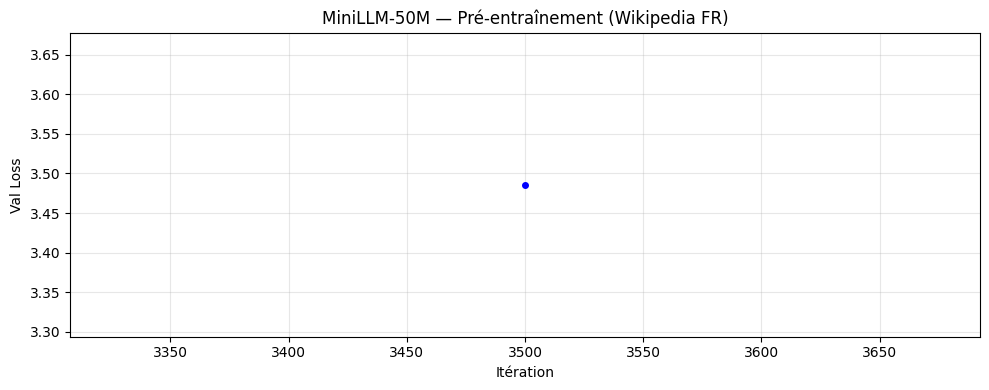

  Meilleure val_loss : 3.4857  (iter 3,500)


In [ ]:
# @title 📈 5.3 — Courbe de loss
import torch, matplotlib.pyplot as plt, glob, os

iters, losses = [], []
for path in sorted(glob.glob(f'{CKPT_PRETRAIN}/*.pt')):
    try:
        c = torch.load(path, map_location='cpu', weights_only=False)
        if c.get('val_loss') and c.get('iter') is not None:
            iters.append(c['iter']); losses.append(c['val_loss'])
    except: pass

if losses:
    plt.figure(figsize=(10,4))
    plt.plot(iters, losses, 'b-o', lw=2, ms=4)
    plt.xlabel('Itération'); plt.ylabel('Val Loss')
    plt.title(f'MiniLLM-{MODEL_SIZE} — Pré-entraînement (Wikipedia FR)')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f'{DRIVE_BASE}/pretrain_loss.png', dpi=150)
    plt.show()
    best_i = losses.index(min(losses))
    print(f'  Meilleure val_loss : {min(losses):.4f}  (iter {iters[best_i]:,})')
else:
    print('  Aucun checkpoint avec val_loss trouvé — lance 5.2 d\'abord.')


---
## 6️⃣ Fine-tuning QA (PIAF)
> Repart du meilleur checkpoint du pré-entraînement et se spécialise sur les 3 835 paires Q/R.
> Même logique de rolling checkpoints (2 max).


In [15]:
# @title ⚙️ 6.1 — Configuration
import sys
sys.path.insert(0, REPO_DIR)
from config import TrainConfig, PRESETS
import os

FT_MAX_ITERS  = 3000   # @param {type:'integer'}
FT_BATCH      = 4      # @param {type:'slider',min:1,max:16,step:1}
FT_ACCUM      = 4      # @param {type:'slider',min:1,max:16,step:1}
FT_SEQ_LEN    = 512    # @param [256,512,1024]
FT_LR         = 5e-5   # @param {type:'number'}

pt_best = os.path.join(CKPT_PRETRAIN, 'best.pt')
assert os.path.exists(pt_best), (
    f'Checkpoint pré-entraînement introuvable : {pt_best}\n'
    f'Lance la section 5 d\'abord !'
)

ft_cfg               = TrainConfig()
ft_cfg.model_size    = MODEL_SIZE
ft_cfg.max_iters     = FT_MAX_ITERS
ft_cfg.batch_size    = FT_BATCH
ft_cfg.grad_accum    = FT_ACCUM
ft_cfg.seq_len       = FT_SEQ_LEN
ft_cfg.lr            = FT_LR
ft_cfg.min_lr        = FT_LR / 10
ft_cfg.warmup_iters  = 100
ft_cfg.compile       = True
ft_cfg.out_dir       = CKPT_FINETUNE
ft_cfg.data_path     = FINETUNE_TRAIN
ft_cfg.val_path      = FINETUNE_VAL
ft_cfg.resume_from   = pt_best
ft_cfg.log_every     = 50
ft_cfg.eval_every    = 300
ft_cfg.save_every    = 1000
ft_cfg.rolling_keep  = ROLLING_KEEP
ft_cfg.reset_iter    = True   # ← CRITIQUE : repart de iter=0 avec les poids du pré-entraînement
                              # Sans ça : iter_start=8000 > max_iters=3000 → boucle vide → rien !

mcfg = PRESETS[MODEL_SIZE]
mcfg.max_seq_len = FT_SEQ_LEN

print(f'{'═'*52}')
print(f'  Fine-tuning QA — MiniLLM-{MODEL_SIZE}')
print(f'{'═'*52}')
print(f'  Depuis         : {pt_best}')
print(f'  Dataset        : PIAF (3 835 paires Q/R françaises)')
print(f'  Itérations     : {FT_MAX_ITERS:,}')
print(f'  LR             : {FT_LR} (< LR pré-entraînement — fine-tuning)')
print(f'  Rolling keep   : {ROLLING_KEEP} checkpoints max')
print(f'{'═'*52}')


════════════════════════════════════════════════════
  Fine-tuning QA — MiniLLM-50M
════════════════════════════════════════════════════
  Depuis         : /content/drive/MyDrive/MiniLLM_v2/checkpoints/pretrain/best.pt
  Dataset        : PIAF (3 835 paires Q/R françaises)
  Itérations     : 3,000
  LR             : 5e-05 (< LR pré-entraînement — fine-tuning)
  Rolling keep   : 2 checkpoints max
════════════════════════════════════════════════════


In [ ]:
# @title 🎯 6.2 — Lancer le fine-tuning
import sys, os, torch
sys.path.insert(0, REPO_DIR)
from train import train

# ── Vérification GPU — le fine-tuning sur CPU est trop lent ──
if not torch.cuda.is_available():
    print('⚠️  Aucun GPU détecté !')
    print('   Le fine-tuning sur CPU serait ~100× plus lent.')
    print('   Options :')
    print('     1. Exécution > Modifier le type d\'exécution > GPU (T4)')
    print('     2. Attendre que le quota GPU Colab se réinitialise (24h)')
    raise SystemExit('❌ GPU requis pour le fine-tuning')

# ── Reprise si un fine-tuning était déjà en cours ──
ft_best = os.path.join(CKPT_FINETUNE, 'best.pt')
if os.path.exists(ft_best):
    print(f'  ♻️  Reprise fine-tuning depuis : {ft_best}')
    ft_cfg.resume_from  = ft_best
    ft_cfg.reset_iter   = False   # reprise réelle : on garde l\'itération
else:
    print(f'  🆕  Fine-tuning depuis les poids du pré-entraînement')
    print(f'      reset_iter=True — repart de iter=0 (poids seuls récupérés)')
    # reset_iter déjà True depuis la cellule 6.1

torch.cuda.empty_cache()
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'\n🚀 Lancement fine-tuning — GPU : {gpu_name} ({vram_gb:.1f} GB)\n')
train(ft_cfg)
print(f'\n✅ Fine-tuning terminé → {CKPT_FINETUNE}/best.pt')


  🆕  Fine-tuning depuis les poids du pré-entraînement
      reset_iter=True — repart de iter=0 (poids seuls récupérés)

🚀 Lancement fine-tuning — GPU : Tesla T4 (15.6 GB)


════════════════════════════════════════════════════════════
  MiniLLM v2 — Entraînement
════════════════════════════════════════════════════════════
  Appareil : cuda  |  Dtype : torch.bfloat16
  Modèle   : MiniLLM-83M | layers=10 d_model=512 heads=8 kv=8 ffn=1408 ctx=512
  Params   : 83.47M
  Batch    : 4 × 4 accum = 16 effectif
  Rolling  : 2 checkpoint(s) numérotés gardés
────────────────────────────────────────────────────────────
  Reprise depuis : /content/drive/MyDrive/MiniLLM_v2/checkpoints/pretrain/best.pt
  Poids chargés depuis iter=9000 → reset iter=0 (fine-tuning)
  Compilation torch.compile...
Optimizer : 83,454,464 params avec weight_decay, 10,752 sans | fused=True

  Données train :
  → 850,761 tokens | ~415 batches
  Données val   :
  → 44,776 tokens | ~21 batches

══════════════════════════════════

/usr/local/lib/python3.13/dist-packages/torch/_inductor/lowering.py:2212: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
W0911 13:32:41.529000 2410 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


iter      0 | val_loss 3.4670 | lr 5.0e-07 | 78.0k tok/s | 31s
  ✅ Nouveau best : val_loss=3.4670 → /content/drive/MyDrive/MiniLLM_v2/checkpoints/finetune/best.pt


/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


  it     0 | loss 3.2526 | lr 5.0e-07 | tokens 0.0M
  it    50 | loss 3.0605 | lr 2.6e-05 | tokens 0.4M


In [ ]:
# @title 📈 6.3 — Courbes comparatives
import torch, matplotlib.pyplot as plt, glob

fig, axes = plt.subplots(1, 2, figsize=(14,4))
configs = [
    (CKPT_PRETRAIN, f'Pré-entr. Wikipedia ({MODEL_SIZE})', 'steelblue'),
    (CKPT_FINETUNE, f'Fine-tuning PIAF ({MODEL_SIZE})',     'darkorange'),
]
for ax, (ckpt_dir, label, color) in zip(axes, configs):
    iters, losses = [], []
    for path in sorted(glob.glob(f'{ckpt_dir}/*.pt')):
        try:
            c = torch.load(path, map_location='cpu', weights_only=False)
            if c.get('val_loss') and c.get('iter') is not None:
                iters.append(c['iter']); losses.append(c['val_loss'])
        except: pass
    if losses:
        ax.plot(iters, losses, color=color, lw=2, marker='o', ms=3)
        ax.set_title(f'{label}\n(meilleure : {min(losses):.4f})')
        ax.set_xlabel('Itération'); ax.set_ylabel('Val Loss')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Pas de données', ha='center', transform=ax.transAxes)
        ax.set_title(label)
plt.suptitle(f'MiniLLM-{MODEL_SIZE} — Courbes d\'entraînement', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/all_losses.png', dpi=150)
plt.show()


---
## 7️⃣ Génération de texte
> Teste les deux modèles : **pré-entraîné** (complétion libre) et **fine-tuné** (QA).


In [ ]:
# @title 📂 7.1 — Charger un modèle
import os, sys
sys.path.insert(0, REPO_DIR)
from generate import load_model

MODELE = 'Pré-entraîné'  # @param ['Pré-entraîné','Fine-tuné QA']

ckpt_path = (os.path.join(CKPT_FINETUNE, 'best.pt')
             if 'QA' in MODELE else
             os.path.join(CKPT_PRETRAIN, 'best.pt'))

assert os.path.exists(ckpt_path), (
    f'Checkpoint introuvable : {ckpt_path}\n'
    f'Lance la section correspondante d\'abord.'
)

gen_model, gen_cfg, gen_device = load_model(ckpt_path)
print(f'✅ Chargé : {MODELE}  ({gen_model.n_params/1e6:.1f}M params) sur {gen_device}')


In [ ]:
# @title ✍️ 7.2 — Complétion de texte libre
import tiktoken, sys
sys.path.insert(0, REPO_DIR)
from generate import generate

PROMPT      = 'La langue française est'  # @param {type:'string'}
MAX_TOKENS  = 150   # @param {type:'slider',min:50,max:400,step:25}
TEMPERATURE = 0.8   # @param {type:'slider',min:0.1,max:1.5,step:0.1}
TOP_K       = 50    # @param {type:'slider',min:0,max:100,step:5}
TOP_P       = 0.95  # @param {type:'slider',min:0.5,max:1.0,step:0.05}

enc    = tiktoken.get_encoding('cl100k_base')
tokens = enc.encode(PROMPT)
out    = generate(gen_model, tokens, MAX_TOKENS, TEMPERATURE, TOP_K, TOP_P, gen_device)
print(f'{'─'*50}')
print(enc.decode(out))
print(f'{'─'*50}')
print(f'({len(out)-len(tokens)} tokens générés)')


In [ ]:
# @title ❓ 7.3 — Mode Question / Réponse
# Fonctionne mieux avec le modèle fine-tuné (section 6)
import tiktoken, sys
sys.path.insert(0, REPO_DIR)
from generate import generate

CONTEXTE   = 'La Tour Eiffel est une tour en fer puddlé de 330 mètres de hauteur, '\
             'construite à Paris en 1889.'  # @param {type:'string'}
QUESTION   = 'Quelle est la hauteur de la Tour Eiffel ?'  # @param {type:'string'}
MAX_TOKENS_QA = 60  # @param {type:'slider',min:20,max:200,step:10}

enc    = tiktoken.get_encoding('cl100k_base')
prompt = (
    f'### Contexte\n{CONTEXTE}\n\n'
    f'### Question\n{QUESTION}\n\n'
    f'### Réponse\n'
)
tokens = enc.encode(prompt)
out    = generate(gen_model, tokens, MAX_TOKENS_QA,
                  temperature=0.3, top_k=20, top_p=0.9, device=gen_device)

answer = enc.decode(out[len(tokens):])
answer = answer.split('<|endoftext|>')[0].split('\n\n')[0].strip()

print(f'{'─'*50}')
print(f'Contexte  : {CONTEXTE}')
print(f'Question  : {QUESTION}')
print(f'{'─'*50}')
print(f'Réponse   : {answer}')
print(f'{'─'*50}')


---
## 8️⃣ Sauvegarde & rolling checkpoints
> Stratégie : **`best.pt` toujours gardé** + seulement les **2 derniers `ckpt_XXXXXX.pt`**.

> ```
> checkpoints/pretrain/
> ├── best.pt           ← toujours conservé (meilleure val_loss)
> ├── ckpt_004000.pt    ← avant-dernier   (gardé)
> └── ckpt_006000.pt    ← dernier         (gardé)
> # ckpt_002000.pt était là, mais a été supprimé automatiquement
> ```


In [ ]:
# @title 📁 8.1 — Résumé des fichiers sur Drive
import os, glob, torch

print(f'{'═'*58}')
print(f'  MiniLLM v2 — Fichiers sur Drive')
print(f'  {DRIVE_BASE}')
print(f'{'═'*58}')

for label, pattern in [
    ('Checkpoints pré-entraînement', f'{CKPT_PRETRAIN}/*.pt'),
    ('Checkpoints fine-tuning',      f'{CKPT_FINETUNE}/*.pt'),
    ('Données tokenisées',           f'{DATA_DIR}/**/*.bin'),
    ('Corpus texte',                 f'{DATA_DIR}/*.txt'),
]:
    files = sorted(glob.glob(pattern, recursive=True))
    files = [f for f in files if os.path.isfile(f)]
    if files:
        total_mb = sum(os.path.getsize(f) for f in files)/1e6
        print(f'\n  {label}  ({total_mb:.0f} MB total)')
        for f in files:
            size_mb = os.path.getsize(f)/1e6
            # Info iter/loss pour les checkpoints
            extra = ''
            if f.endswith('.pt'):
                try:
                    c = torch.load(f, map_location='cpu', weights_only=False)
                    it  = c.get('iter','?')
                    vl  = c.get('val_loss')
                    extra = f'iter={it}' + (f' val_loss={vl:.4f}' if vl else '')
                except: extra = '(illisible)'
            print(f'    {os.path.basename(f):28s} {size_mb:6.0f} MB  {extra}')

print(f'\n{'═'*58}')


In [ ]:
# @title 🔄 8.2 — Nettoyage manuel rolling (si nécessaire)
import os, glob
from train import _rolling_cleanup

DOSSIER = 'Pré-entraînement'  # @param ['Pré-entraînement','Fine-tuning']
GARDER  = 2                    # @param {type:'slider',min:1,max:5,step:1}

ckpt_dir = CKPT_PRETRAIN if DOSSIER == 'Pré-entraînement' else CKPT_FINETUNE

avant = sorted(glob.glob(f'{ckpt_dir}/ckpt_*.pt'))
print(f'Avant nettoyage ({len(avant)} ckpt numérotés) :')
for f in avant: print(f'  {os.path.basename(f)}')

n_removed = _rolling_cleanup(ckpt_dir, keep=GARDER)

apres = sorted(glob.glob(f'{ckpt_dir}/ckpt_*.pt'))
print(f'\nAprès ({len(apres)} ckpt) — {n_removed} supprimé(s) :')
for f in apres: print(f'  ✅ {os.path.basename(f)}')
if os.path.exists(os.path.join(ckpt_dir, 'best.pt')):
    print(f'  ✅ best.pt  (toujours conservé)')


In [ ]:
# @title 📥 8.3 — Télécharger un modèle sur ton PC
from google.colab import files
import os

TELECHARGER = 'Fine-tuné QA (best.pt)'  # @param ['Pré-entraîné (best.pt)','Fine-tuné QA (best.pt)']

path = (os.path.join(CKPT_FINETUNE, 'best.pt') if 'QA' in TELECHARGER
        else os.path.join(CKPT_PRETRAIN, 'best.pt'))

if os.path.exists(path):
    size_mb = os.path.getsize(path)/1e6
    print(f'Téléchargement : {os.path.basename(path)}  ({size_mb:.0f} MB)...')
    files.download(path)
else:
    print(f'❌ Fichier introuvable : {path}')
    print(f'   Lance la section 5 (pré-entraînement) ou 6 (fine-tuning) d\'abord.')


In [ ]:
# @title 📤 8.4 — Uploader un checkpoint (reprendre sur Colab)
from google.colab import files
import shutil, os

DESTINATION = 'Pré-entraînement'  # @param ['Pré-entraînement','Fine-tuning']
dest_dir = CKPT_PRETRAIN if DESTINATION == 'Pré-entraînement' else CKPT_FINETUNE

print('Sélectionne ton fichier best.pt...')
uploaded = files.upload()
for fname in uploaded:
    dest = os.path.join(dest_dir, 'best.pt')
    shutil.move(fname, dest)
    print(f'✅ Uploadé → {dest}')
print('Tu peux maintenant relancer la section 5 ou 6 (reprise automatique).')


---
## 🎁 Conseils & prochaines étapes

### Améliorer les performances

| Action | Impact estimé |
|--------|---------------|
| `WIKI_FRACTION = '20%'` → plus de texte | +++++ |
| Augmenter `PT_MAX_ITERS` | ++++ |
| Passer à `MODEL_SIZE = '125M'` | +++ |
| Ajouter un corpus Fulfulde (projet Tardigrade) | +++ |
| Entraîner un tokenizer custom fr+fuv | ++ |

### Intégrer tes données Fulfulde
```python
# Dans la cellule 3.1, après le téléchargement Wikipedia :
import os
FULFULDE_FILE = '/content/drive/MyDrive/corpus_fulfulde.txt'   # ton corpus
if os.path.exists(FULFULDE_FILE):
    with open(WIKI_CACHE, 'a', encoding='utf-8') as out:
        with open(FULFULDE_FILE, encoding='utf-8') as f:
            out.write('\n\n' + f.read())
    print('✅ Corpus Fulfulde ajouté à Wikipedia FR')
```

### Liens
- 📦 Repo : https://github.com/bono-p/minillm_v2
- 📚 PIAF : https://huggingface.co/datasets/etalab-ia/piaf
- 🌐 Wikipedia : https://huggingface.co/datasets/wikimedia/wikipedia
